# Mapa de calor de correlación

In [1]:
import gwaslab as gl
import pandas as pd

In [2]:
gl.show_version()

2026/03/19 12:04:11 GWASLab v4.1.2 https://cloufield.github.io/gwaslab/
2026/03/19 12:04:11 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/03/19 12:04:11 Python version: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:51:19) [Clang 19.1.7 ]


## Cargar datos de muestra

Fuente de datos de ejemplo:

- Kanai, M., Akiyama, M., Takahashi, A., Matoba, N., Momozawa, Y., Ikeda, M., ... & Kamatani, Y. (2018). Genetic analysis of quantitative traits in the Japanese population links cell types to complex human diseases. Nature genetics, 50(3), 390-400.

In [3]:
ldsc = pd.read_csv("../0_sample_data/toy_data/input_rg.txt",sep="\t")
ldsc

,p1_category,p1,p2_category,p2,rg,se,z,p,q
0,Anthropometric,Height,Anthropometric,BMI,-0.0587,0.0240,-2.4421,0.014602,0.136798
1,Anthropometric,Height,Metabolic,TC,-0.0778,0.0344,-2.2634,0.023611,0.188695
2,Anthropometric,Height,Metabolic,HDL-C,-0.0045,0.0364,-0.1230,0.902080,0.971590
3,Anthropometric,Height,Metabolic,LDL-C,-0.1245,0.0426,-2.9228,0.003469,0.050126
4,Anthropometric,Height,Metabolic,TG,-0.0426,0.0309,-1.3792,0.167820,0.523652
...,...,...,...,...,...,...,...,...,...
3911,Other,Pollinosis,Tumor,PrCa,0.3250,0.1433,2.2683,0.023300,0.187944
3912,Other,Pollinosis,Tumor,UF,0.2163,0.1756,1.2315,0.218100,0.596616
3913,Other,Pollinosis,Other,Urolithiasis,0.0664,0.1794,0.3701,0.711300,0.903018
3914,Other,Urolithiasis,Allergic disease,AD,-0.0821,0.1592,-0.5159,0.605890,0.863730


## Mapa de calor completo

2026/03/19 12:05:46 Start to create ldsc genetic correlation heatmap...
2026/03/19 12:05:46 Configured plot style for plot_rg:None
2026/03/19 12:05:46 Raw dataset records: 3916
2026/03/19 12:05:46  -Raw dataset non-NA records: 3916
2026/03/19 12:05:46 Filling diagonal line and duplicated pair for plotting...
2026/03/19 12:05:46  -Diagonal records: 89
2026/03/19 12:05:47 Valid unique trait pairs: 3916
2026/03/19 12:05:47  -Valid unique trait1: 88
2026/03/19 12:05:47  -Valid unique trait2: 88
2026/03/19 12:05:47  -Significant correlations with P < 0.05: 270
2026/03/19 12:05:47  -Significant correlations after Bonferroni correction: 81
2026/03/19 12:05:47  -Significant correlations with FDR <0.05: 127
2026/03/19 12:05:47 Plotting heatmap...
2026/03/19 12:05:47 Full cell : non-corrected P == 0.05
2026/03/19 12:05:56 P value annotation text (Order: Bon -> FDR -> Pnom): 
2026/03/19 12:05:56  -* : non-corrected P < 0.05 
2026/03/19 12:05:56 Finished creating ldsc genetic correlation heatmap!


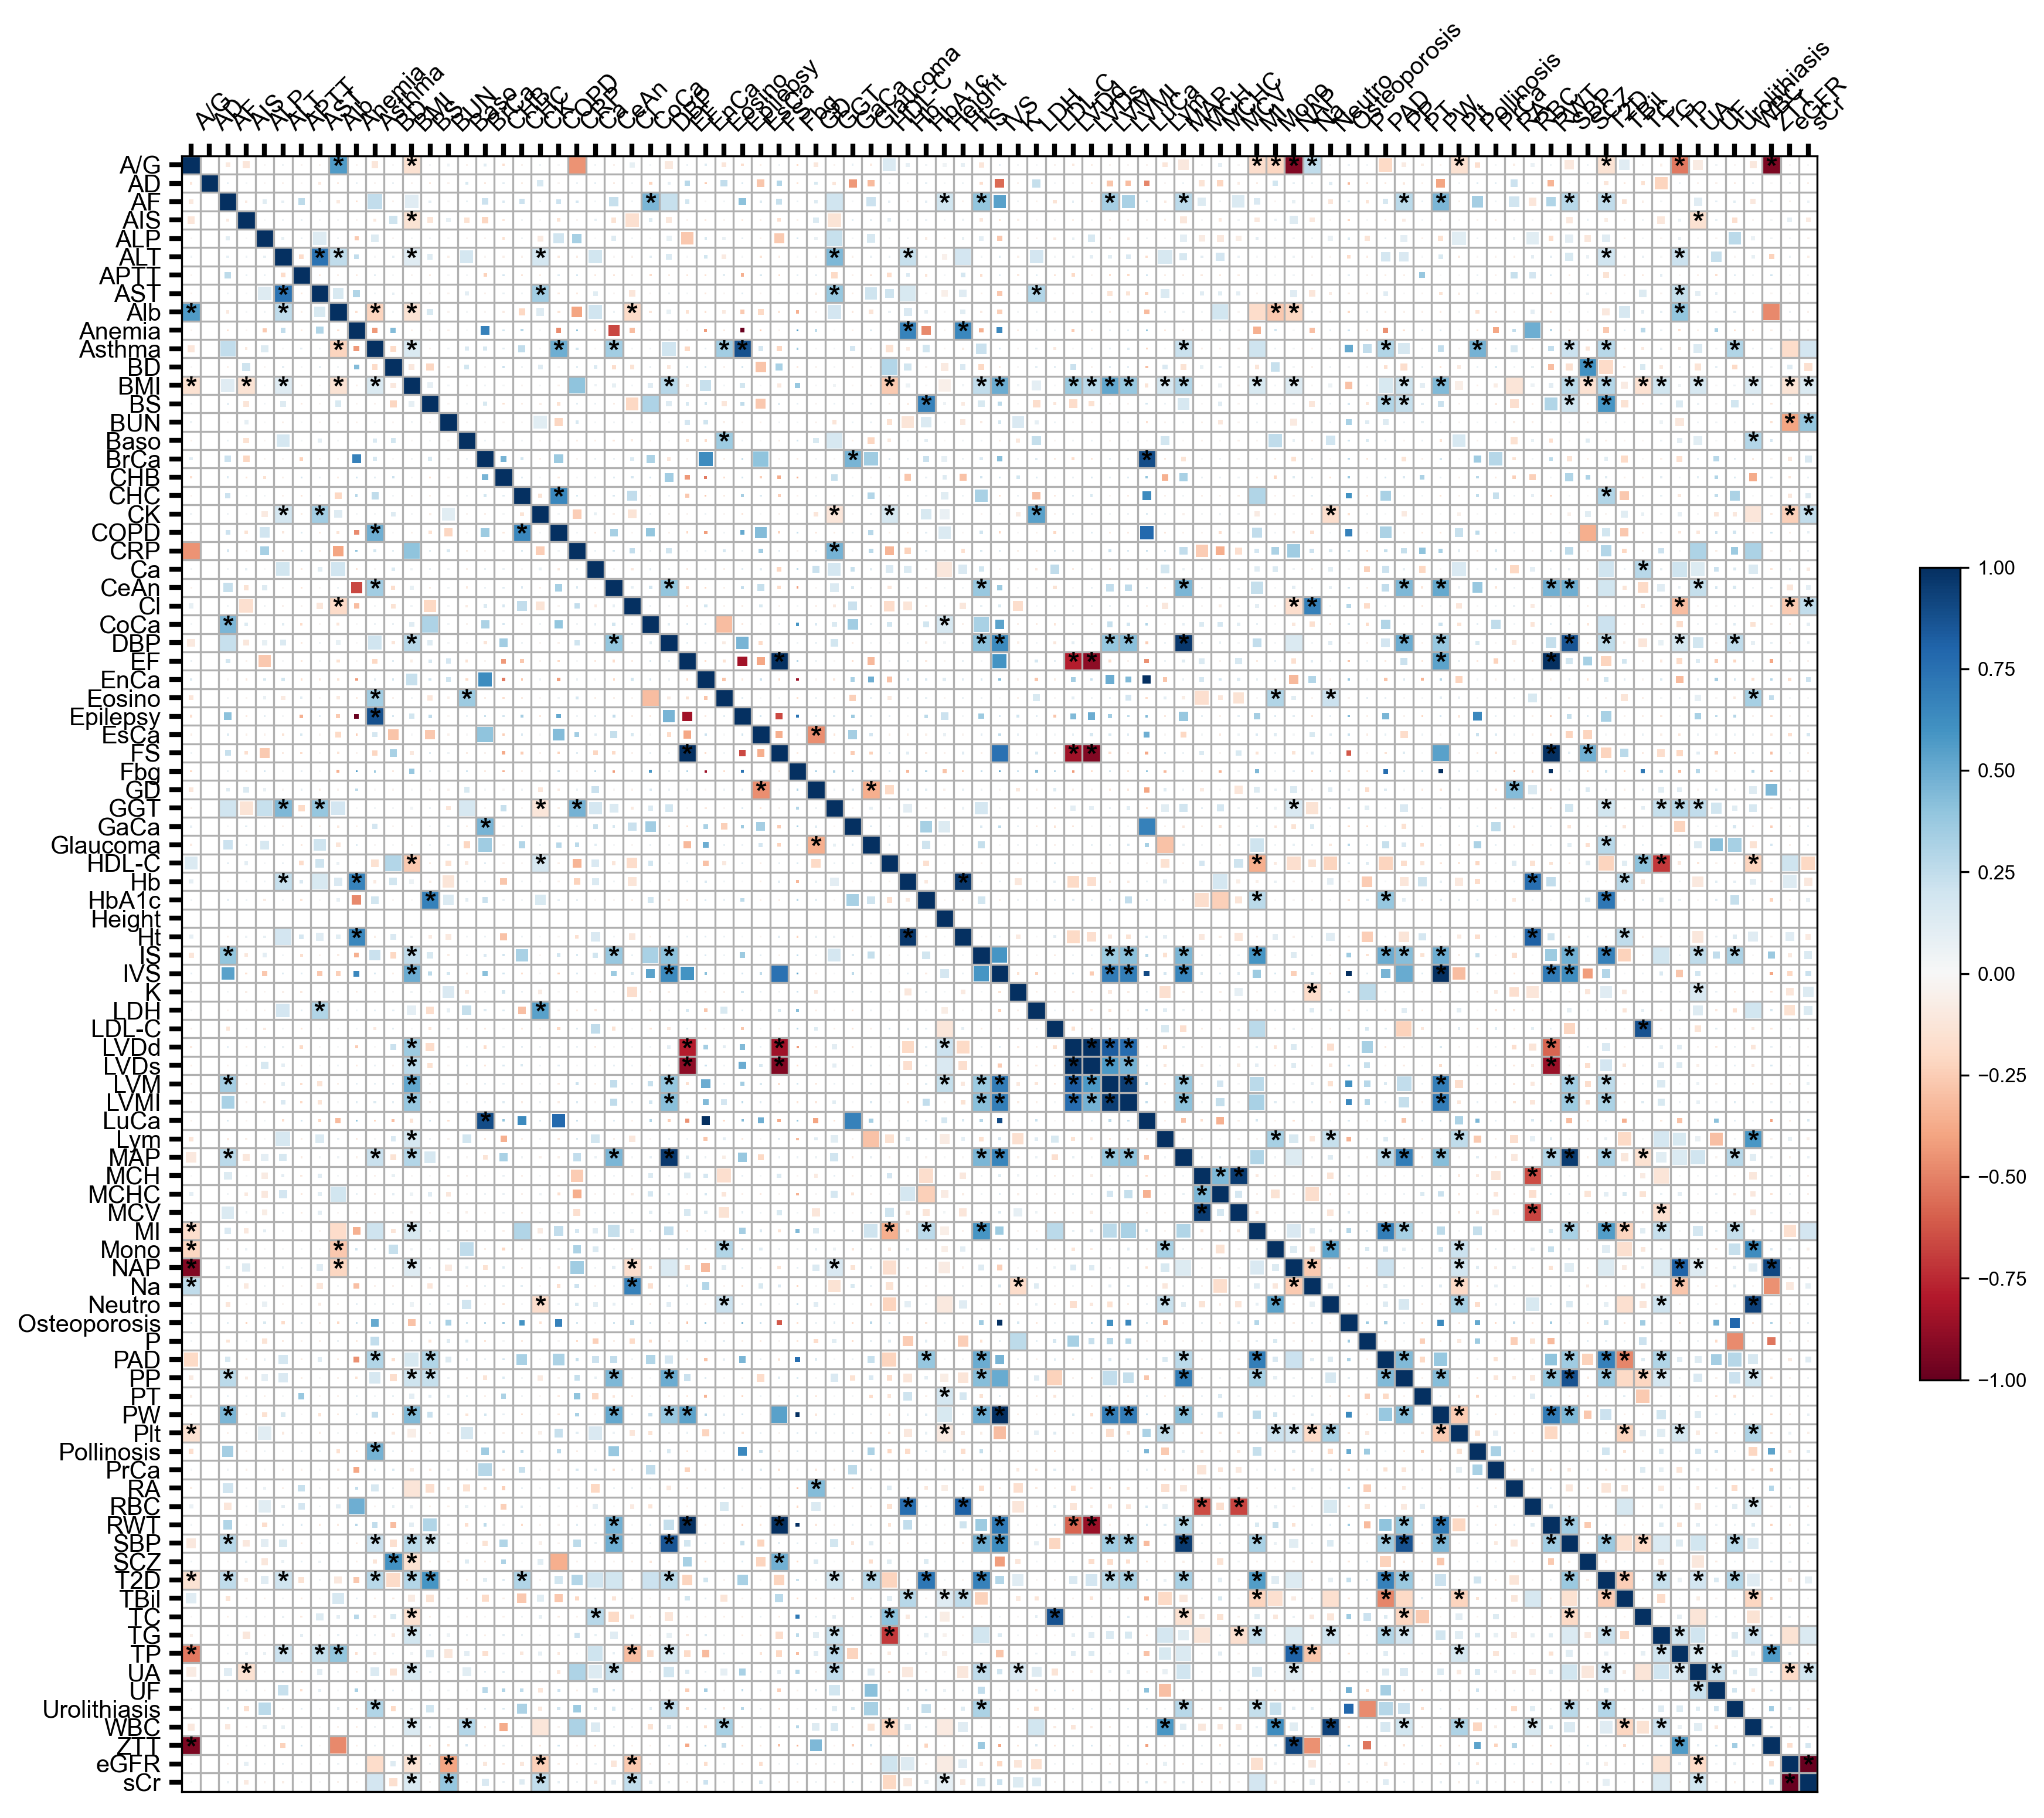

In [5]:
df = gl.plot_rg(ldsc,
                p="q",
                p1="p2",
                p2="p1",
                sig_levels=[0.05],
                corrections=["non"],
                full_cell=("non", 0.05),
                panno_texts=["*"],
                panno_kwargs={"size": 12, "c": "black"},      # <-- cambio aquí
                fig_kwargs={"figsize": (15, 15), "dpi": 300}, # <-- probable cambio
                colorbar_kwargs={"shrink": 0.4},              # <-- probable cambio
                fontsize=8)

## Filtrar y ordenar los datos

In [6]:
# Order the data
trait =  pd.read_csv("../0_sample_data/toy_data/trait_list.txt",sep="\t")
trait["order"] = range(len(trait))
trait

# These steps are just used to order the traits

order = trait["TRAIT"].values

trait_set1 = trait.loc[trait["order"]>=59,"TRAIT"].values
trait_set2 = trait.loc[trait["order"]<59,"TRAIT"].values

ldsc = ldsc.loc[((ldsc["p1"].isin(trait_set1))&(ldsc["p2"].isin(trait_set2))) | ((ldsc["p1"].isin(trait_set2))&(ldsc["p2"].isin(trait_set1))),:]

# key for sort
map_dic={order[i]:i+1 for i in range(len(order))}
key=lambda x:x.map(map_dic)

In [7]:
print(map_dic)

{'Height': 1, 'BMI': 2, 'TC': 3, 'HDL-C': 4, 'LDL-C': 5, 'TG': 6, 'BS': 7, 'HbA1c': 8, 'TP': 9, 'Alb': 10, 'NAP': 11, 'A/G': 12, 'BUN': 13, 'sCr': 14, 'eGFR': 15, 'UA': 16, 'Na': 17, 'K': 18, 'Cl': 19, 'Ca': 20, 'P': 21, 'TBil': 22, 'ZTT': 23, 'AST': 24, 'ALT': 25, 'ALP': 26, 'GGT': 27, 'APTT': 28, 'PT': 29, 'Fbg': 30, 'CK': 31, 'LDH': 32, 'CRP': 33, 'WBC': 34, 'Neutro': 35, 'Eosino': 36, 'Baso': 37, 'Mono': 38, 'Lym': 39, 'RBC': 40, 'Hb': 41, 'Ht': 42, 'MCV': 43, 'MCH': 44, 'MCHC': 45, 'Plt': 46, 'SBP': 47, 'DBP': 48, 'MAP': 49, 'PP': 50, 'IVS': 51, 'PW': 52, 'LVDd': 53, 'LVDs': 54, 'LVM': 55, 'LVMI': 56, 'RWT': 57, 'FS': 58, 'EF': 59, 'T2D': 60, 'IS': 61, 'CeAn': 62, 'MI': 63, 'PAD': 64, 'AF': 65, 'Asthma': 66, 'AD': 67, 'GD': 68, 'RA': 69, 'CHB': 70, 'CHC': 71, 'Anemia': 72, 'BD': 73, 'SCZ': 74, 'AIS': 75, 'Osteoporosis': 76, 'LuCa': 77, 'GaCa': 78, 'EsCa': 79, 'CoCa': 80, 'PrCa': 81, 'BrCa': 82, 'EnCa': 83, 'UF': 84, 'Glaucoma': 85, 'COPD': 86, 'Epilepsy': 87, 'Pollinosis': 88, 'Ur

## Reproducir el mapa de calor en papel

2026/03/19 12:07:04 Start to create ldsc genetic correlation heatmap...
2026/03/19 12:07:04 Configured plot style for plot_rg:None
2026/03/19 12:07:04 Raw dataset records: 1770
2026/03/19 12:07:04  -Raw dataset non-NA records: 1770
2026/03/19 12:07:04 Filling diagonal line and duplicated pair for plotting...
2026/03/19 12:07:04 Valid unique trait pairs: 1770
2026/03/19 12:07:04  -Valid unique trait1: 59
2026/03/19 12:07:04  -Valid unique trait2: 30
2026/03/19 12:07:04  -Significant correlations with P < 0.05: 68
2026/03/19 12:07:04  -Significant correlations after Bonferroni correction: 13
2026/03/19 12:07:04  -Significant correlations with FDR <0.05: 20
2026/03/19 12:07:04 Plotting heatmap...
2026/03/19 12:07:04 Full cell : non-corrected P == 0.05
2026/03/19 12:07:05 P value annotation text (Order: Bon -> FDR -> Pnom): 
2026/03/19 12:07:05  -* : non-corrected P < 0.05 
2026/03/19 12:07:05 Finished creating ldsc genetic correlation heatmap!


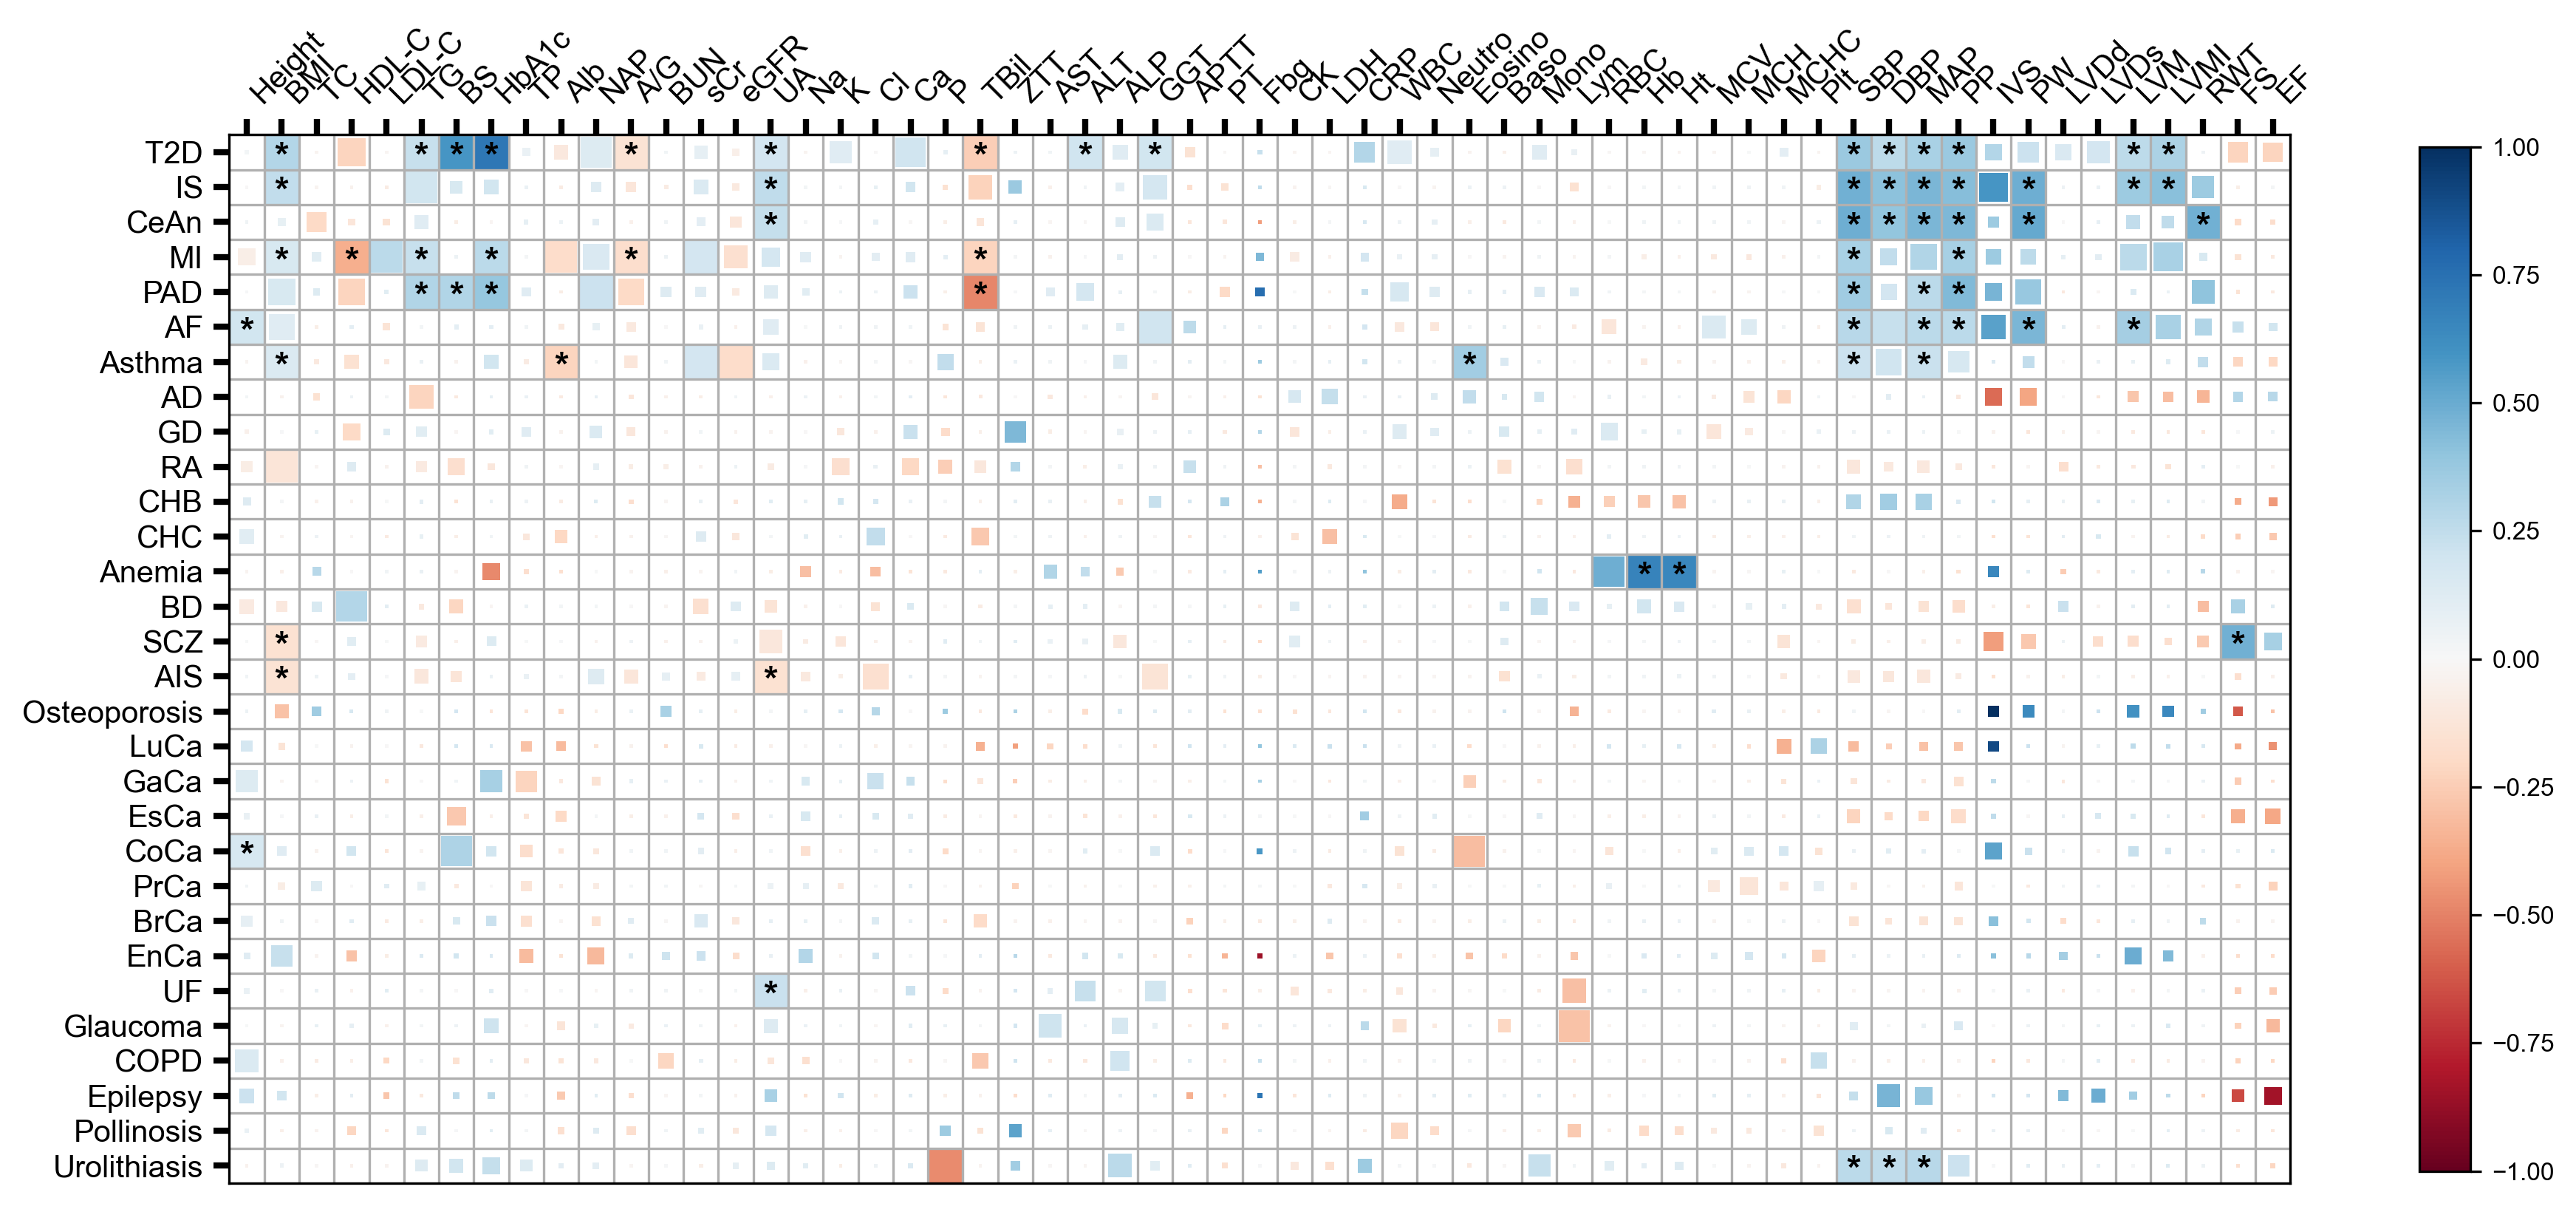

In [9]:
df = gl.plot_rg(ldsc,
                sig_levels=[0.05],
                corrections=["non"],
                p="q",
                p1="p2",
                p2="p1",
                full_cell=("non", 0.05),
                panno_texts=["*"],
                fig_kwargs={"figsize": (15, 15), "dpi": 300},      # antes fig_args
                colorbar_kwargs={"shrink": 0.4},                   # antes colorbar_args
                panno_kwargs={"size": 12, "c": "black"},           # antes panno_args
                fontsize=8,
                sort_key=key)                                       # key debe estar definido